In [1]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive


In [2]:
import shutil

# Dataset details
DATASET_SLUG = "robinreni/revitsone-5class"
LOCAL_DATA_PATH = "/content/driver_data"

# Download and Unzip to local SSD
if not os.path.exists(LOCAL_DATA_PATH):
    print("📥 Downloading dataset...")
    !kaggle datasets download -d {DATASET_SLUG}
    !unzip -q revitsone-5class.zip -d {LOCAL_DATA_PATH}
    os.remove("revitsone-5class.zip")
    print("Dataset ready on local.")

📥 Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/robinreni/revitsone-5class
License(s): DbCL-1.0
 96% 939M/983M [00:04<00:00, 269MB/s]
100% 983M/983M [00:04<00:00, 239MB/s]
✅ Dataset ready on local SSD.


In [ ]:
import os
from PIL import Image

# The path where images are located
data_dir = "/content/driver_data/Revitsone-5classes"

print("Starting Scan for corrupted images...")

num_skipped = 0
num_deleted = 0

for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            # 1. Try to open the image
            img = Image.open(file_path)

            # 2. Verify the internal integrity (checks for truncation/header errors)
            img.verify()

            # 3. Re-open to check if we can actually load the pixels
            # (verify() closes the file, so we re-open)
            img = Image.open(file_path)
            img.load()

        except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
            print(f"Deleting corrupted/invalid file: {file_path}")
            os.remove(file_path)
            num_deleted += 1
        except Exception as e:
            print(f"Unexpected error with {file}: {e}")
            os.remove(file_path)
            num_deleted += 1

print(f"\n Scan Complete!")
print(f"Total corrupted files removed: {num_deleted}")

🔍 Starting Deep Scan for corrupted images...
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/turning/img_62337.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/turning/img_8771.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/turning/img_67523.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/turning/img_70552.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/turning/img_84605.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/turning/img_101434.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/other_activities/img_13541.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/other_activities/img_4664.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/Revitsone-5classes/other_activities/img_20398.jpg
❌ Deleting corrupted/invalid file: /content/driver_data/

In [12]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{LOCAL_DATA_PATH}/Revitsone-5classes",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{LOCAL_DATA_PATH}/Revitsone-5classes",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Optimize performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 10751 files belonging to 5 classes.
Using 8601 files for training.
Found 10751 files belonging to 5 classes.
Using 2150 files for validation.


In [13]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Extract labels from the training dataset
print("Calculating class weights...")
y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_integers = np.argmax(y_train, axis=1)

# 2. Compute weights to balance the 5 classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

class_weight_dict = dict(enumerate(weights))
print(f"Class Weights calculated: {class_weight_dict}")

📊 Calculating class weights...
✅ Class Weights calculated: {0: np.float64(1.0130742049469965), 1: np.float64(0.9835334476843911), 2: np.float64(0.9829714285714286), 3: np.float64(0.9801709401709402), 4: np.float64(1.043177683444512)}


In [14]:
from tensorflow.keras import layers, models

# 1. Base Model: MobileNetV2 (Pre-trained on ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base layers

# 2. Add Custom Head for 5 Classes
model = models.Sequential([
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Prevent overfitting
    layers.Dense(5, activation='softmax') # 5 classes for driver foul detection
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define Early Stopping (Stops if validation loss doesn't improve for 3 epochs)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 2. Define Model Checkpoint (Saves the 'best' version of the model automatically)
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_driver_model_tested.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 3. Train with Class Weights and Callbacks
print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Increased max epochs because Early Stopping will cut it short if needed
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint]
)

🚀 Starting training...
Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4463 - loss: 1.3693
Epoch 1: val_accuracy improved from -inf to 0.82977, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 542s 2s/step - accuracy: 0.4468 - loss: 1.3681 - val_accuracy: 0.8298 - val_loss: 0.6302
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7819 - loss: 0.6467
Epoch 2: val_accuracy improved from 0.82977 to 0.88186, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.7820 - loss: 0.6465 - val_accuracy: 0.8819 - val_loss: 0.4585
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8363 - loss: 0.5007
Epoch 3: val_accuracy improved from 0.88186 to 0.90000, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 489s 2s/step - accuracy: 0.8363 - loss: 0.5006 - val_accuracy: 0.9000 - val_loss: 0.3836
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8623 - loss: 0.4309
Epoch 4: val_accuracy improved from 0.90000 to 0.91953, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.8623 - loss: 0.4309 - val_accuracy: 0.9195 - val_loss: 0.3257
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8760 - loss: 0.3816
Epoch 5: val_accuracy did not improve from 0.91953
269/269 ━━━━━━━━━━━━━━━━━━━━ 531s 2s/step - accuracy: 0.8760 - loss: 0.3816 - val_accuracy: 0.9102 - val_loss: 0.3092
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8861 - loss: 0.3511
Epoch 6: val_accuracy improved from 0.91953 to 0.93163, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


...

269/269 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.8928 - loss: 0.3165 - val_accuracy: 0.9381 - val_loss: 0.2444
Epoch 9/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9004 - loss: 0.3017
Epoch 9: val_accuracy improved from 0.93814 to 0.94093, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 488s 2s/step - accuracy: 0.9004 - loss: 0.3017 - val_accuracy: 0.9409 - val_loss: 0.2324
Epoch 10/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9009 - loss: 0.2906
Epoch 10: val_accuracy did not improve from 0.94093
269/269 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.9009 - loss: 0.2906 - val_accuracy: 0.9353 - val_loss: 0.2274
Epoch 11/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9164 - loss: 0.2639
Epoch 11: val_accuracy did not improve from 0.94093
269/269 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.9164 - loss: 0.2639 - val_accuracy: 0.9409 - val_loss: 0.2122
Epoch 12/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9095 - loss: 0.2692
Epoch 12: val_accuracy improved from 0.94093 to 0.94558, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - accuracy: 0.9095 - loss: 0.2692 - val_accuracy: 0.9456 - val_loss: 0.2055
Epoch 13/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9095 - loss: 0.2726
Epoch 13: val_accuracy did not improve from 0.94558
269/269 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.9095 - loss: 0.2726 - val_accuracy: 0.9372 - val_loss: 0.2168
Epoch 14/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9084 - loss: 0.2740
Epoch 14: val_accuracy did not improve from 0.94558
269/269 ━━━━━━━━━━━━━━━━━━━━ 474s 2s/step - accuracy: 0.9084 - loss: 0.2739 - val_accuracy: 0.9447 - val_loss: 0.1952
Epoch 15/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9129 - loss: 0.2560
Epoch 15: val_accuracy did not improve from 0.94558
269/269 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.9129 - loss: 0.2560 - val_accuracy: 0.9447 - val_loss: 0.1965
Epoch 16/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9177 - loss: 0.2440
Epoch 16: val_accuracy impro

269/269 ━━━━━━━━━━━━━━━━━━━━ 530s 2s/step - accuracy: 0.9177 - loss: 0.2440 - val_accuracy: 0.9465 - val_loss: 0.1980
Epoch 17/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9096 - loss: 0.2594
Epoch 17: val_accuracy did not improve from 0.94651
269/269 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.9096 - loss: 0.2594 - val_accuracy: 0.9456 - val_loss: 0.1934
Epoch 18/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9144 - loss: 0.2509
Epoch 18: val_accuracy did not improve from 0.94651
269/269 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.9144 - loss: 0.2509 - val_accuracy: 0.9353 - val_loss: 0.2123
Epoch 19/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9181 - loss: 0.2465
Epoch 19: val_accuracy improved from 0.94651 to 0.95256, saving model to /content/drive/MyDrive/best_driver_model_tested.h5


269/269 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - accuracy: 0.9181 - loss: 0.2465 - val_accuracy: 0.9526 - val_loss: 0.1809
Epoch 20/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9183 - loss: 0.2341
Epoch 20: val_accuracy did not improve from 0.95256
269/269 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.9183 - loss: 0.2341 - val_accuracy: 0.9358 - val_loss: 0.2096
Restoring model weights from the end of the best epoch: 19.


📸 Testing image: /content/driver_data/Revitsone-5classes/texting_phone/img_15799.jpg
🏷️ Actual Label: texting_phone


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


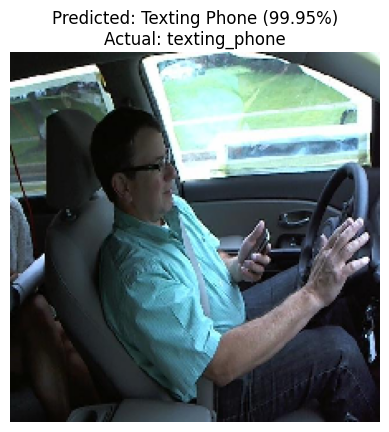

In [23]:
import os
import random
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the model with the custom_objects fix
model_path = '/content/drive/MyDrive/best_driver_model_tested.h5'
model = tf.keras.models.load_model(
    model_path,
    custom_objects={'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input}
)

# 2. Define the exact class names used by the data loader
class_names = ['Other Activities', 'Safe Driving', 'Talking Phone', 'Texting Phone', 'Turning']

def test_random_image():
    base_path = "/content/driver_data/Revitsone-5classes"

    # Pick a random class folder
    random_class = random.choice(os.listdir(base_path))
    class_dir = os.path.join(base_path, random_class)

    # Pick a random image from that folder
    random_file = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, random_file)

    print(f" Testing image: {img_path}")
    print(f" Actual Label: {random_class}")

    # Load and process image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = 100 * np.max(predictions)

    # Display
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\nActual: {random_class}")
    plt.axis('off')
    plt.show()

# Run the test
test_random_image()

🧪 Gathering data for evaluation...


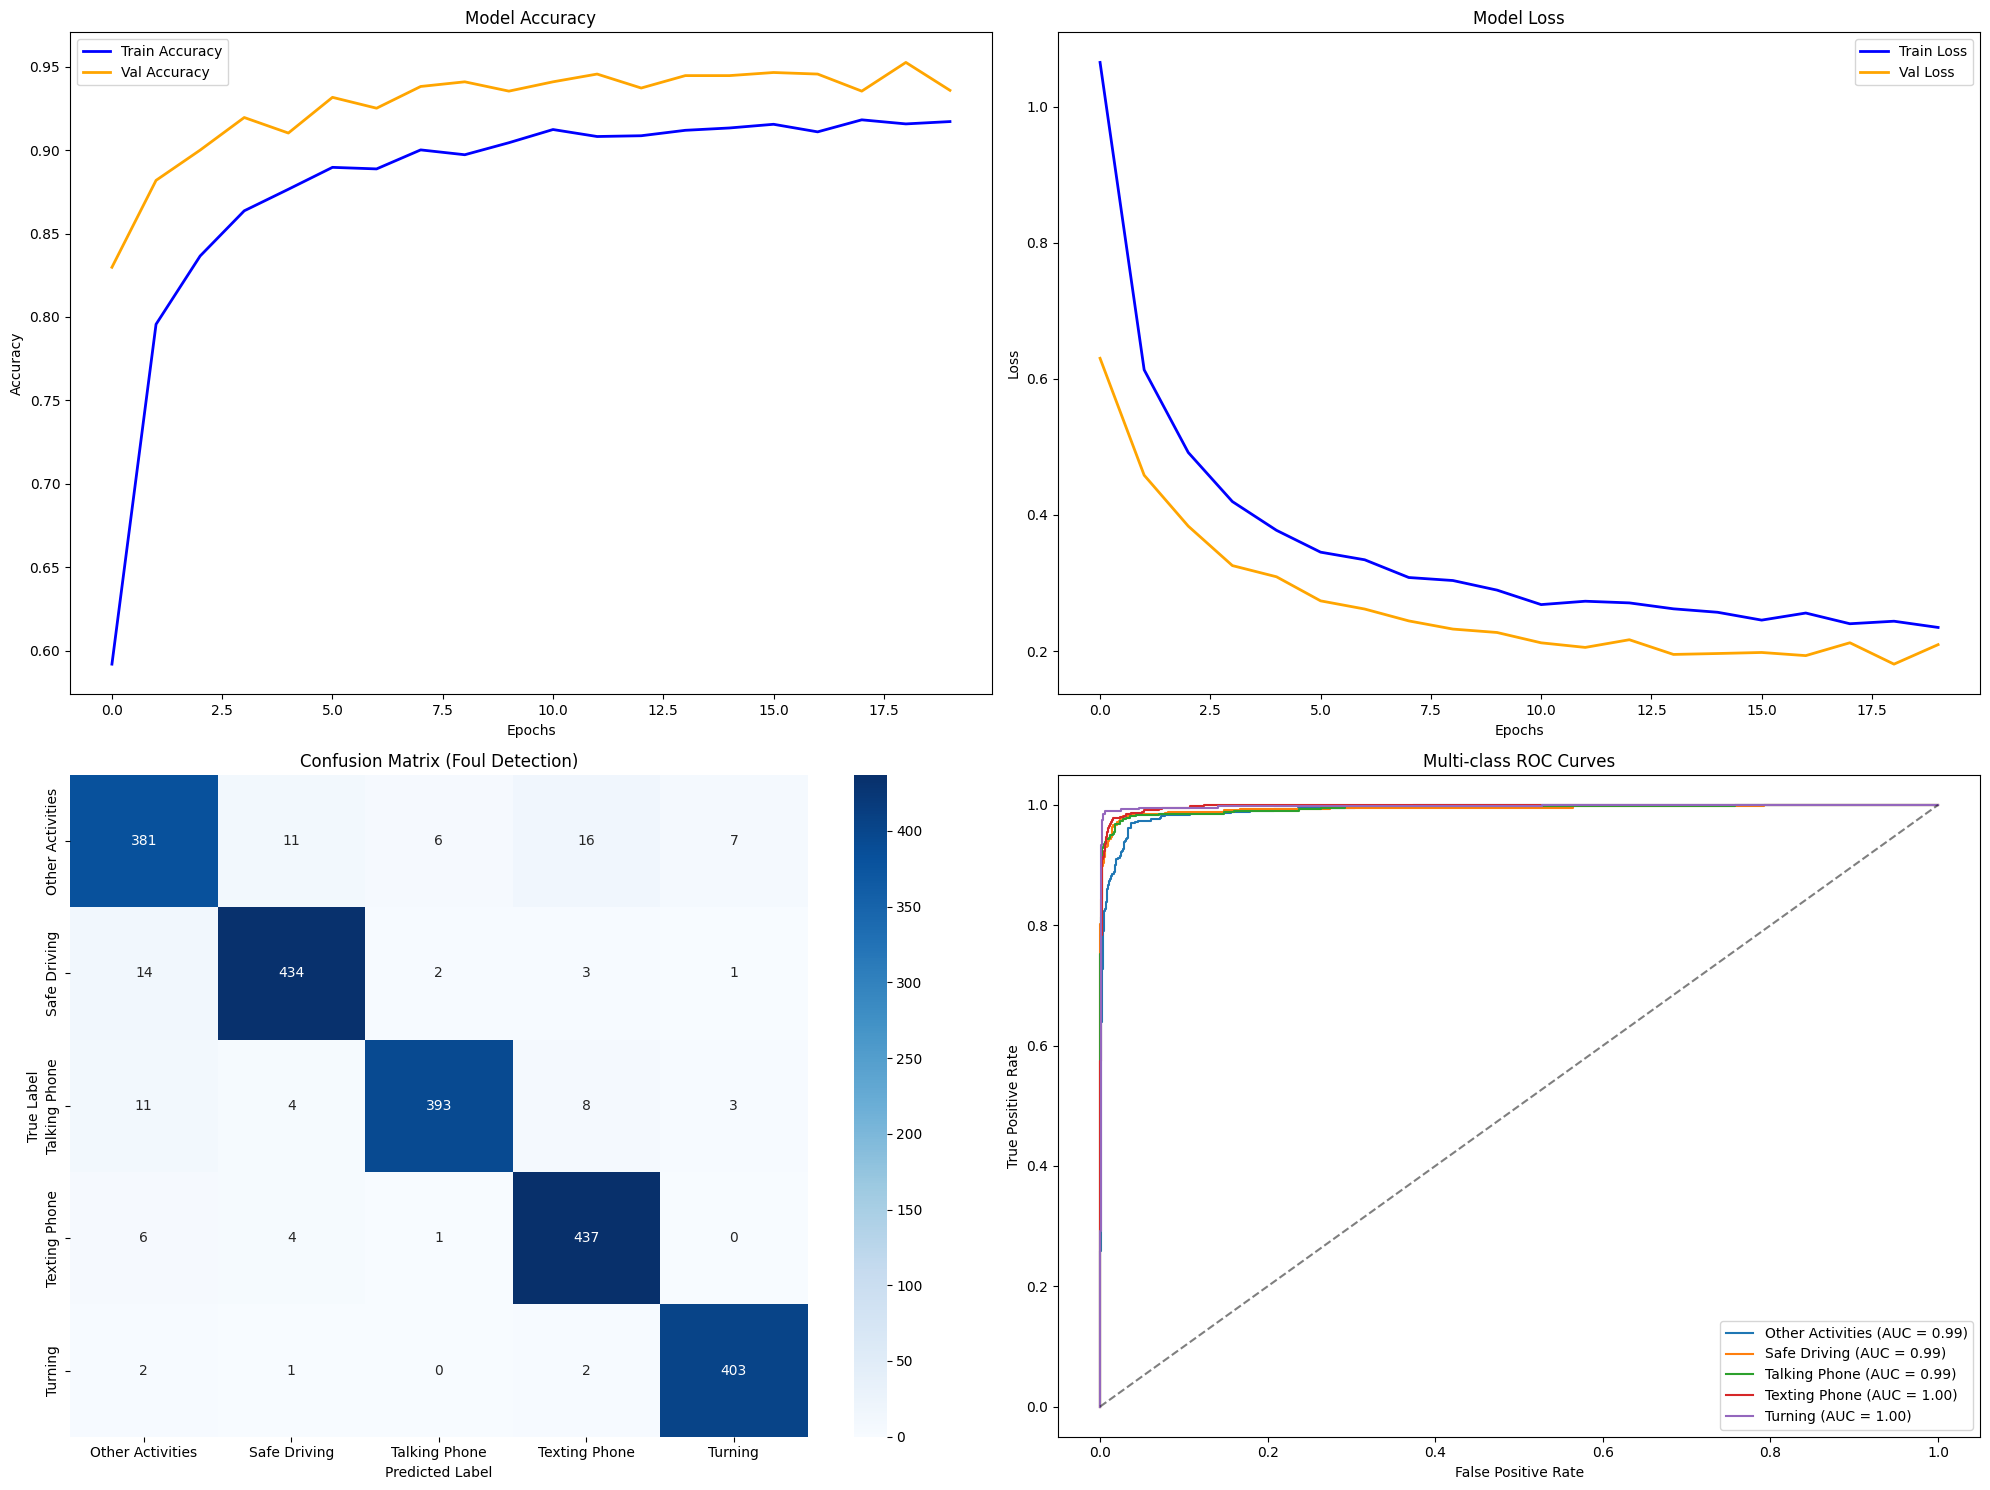


📝 Detailed Classification Report:

                  precision    recall  f1-score   support

Other Activities       0.92      0.90      0.91       421
    Safe Driving       0.96      0.96      0.96       454
   Talking Phone       0.98      0.94      0.96       419
   Texting Phone       0.94      0.98      0.96       448
         Turning       0.97      0.99      0.98       408

        accuracy                           0.95      2150
       macro avg       0.95      0.95      0.95      2150
    weighted avg       0.95      0.95      0.95      2150



In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup Class Names
class_names = ['Other Activities', 'Safe Driving', 'Talking Phone', 'Texting Phone', 'Turning']

# 2. Collect Data & Predictions
print("Gathering data for evaluation...")
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred_probs.extend(probs)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Visualization: Training History, Confusion Matrix, and ROC
def perform_full_evaluation(history, y_true, y_pred, y_pred_probs, class_names):
    plt.figure(figsize=(20, 15))

    # --- Plot A: Accuracy ---
    plt.subplot(2, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', lw=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', lw=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # --- Plot B: Loss ---
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange', lw=2)
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # --- Plot C: Confusion Matrix ---
    plt.subplot(2, 2, 3)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Foul Detection)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # --- Plot D: ROC Curves ---
    plt.subplot(2, 2, 4)
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title('Multi-class ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# 4. Execute Visualization & Report
perform_full_evaluation(history, y_true, y_pred, y_pred_probs, class_names)

print("\n Detailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [27]:
model.save('/content/drive/MyDrive/best_driver_model.keras')

In [28]:
# Save just the weights
model.save_weights('/content/drive/MyDrive/driver_model_weights.weights.h5')